In [1]:
# run with env_faster.yml environment
import torch
torch.set_float32_matmul_precision("high")
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt
import shapiq 
import src

### load model

In [2]:
from transformers import AutoProcessor, AutoModel

model = AutoModel.from_pretrained("google/siglip-base-patch16-224")
model.to("cuda")
processor = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


### load data

In [3]:
input_text = "black dog next to a yellow hydrant"
# input_image = Image.open("assets/dog_and_hydrant.png")
input_image = Image.open("assets/dog_and_hydrant.png").convert("RGB")

### define game

In [4]:
from shapiq.imputer.vision import VisionImputerFactory
from shapiq.imputer.vision import VisionLanguageGame

factory = VisionImputerFactory()

# Original ViT path: uses the default patch-grid segmenter.
# imputer = factory.build(model, processor, input_image, input_text)

# CLIP-ResNet + SLIC path: required for CNN backbones because they do not have ViT patches.

imputer = factory.build(model, processor, input_image, input_text, segmenter_config=None, masker_config=None)

game = VisionLanguageGame(imputer, batch_size=32)
n_players_image = game.n_players_image
n_players_text = game.n_players_text

### define approximator

In [5]:
fixlip = src.fixlip.FIxLIP(
    n_players_image=n_players_image,
    n_players_text=n_players_text, 
    max_order=2,
    p=0.5, # weight
    mode="banzhaf",
    random_state=0
)

### compute explanation

In [6]:
src.utils.set_seed(0)
interaction_values = fixlip.approximate_crossmodal(game, budget=2**14, approximation_type="proxyshap")       

### save explanation

In [7]:
# interaction_values.save("results/dog_and_hydrant_fixlip.pkl")

### visualize explanation

In [8]:
# interaction_values = shapiq.InteractionValues.load("results/dog_and_hydrant_fixlip.pkl")
print(interaction_values)

InteractionValues(
    index=FBII, max_order=2, min_order=0, estimated=True, estimation_budget=16384,
    n_players=207, baseline_value=-11.799905776977539,
    Top 10 interactions:
        (201,): 8.319144103978488
        (204,): 2.6495512015753775
        (196,): 1.7006167593158352
        (197, 201): 1.6741263670264743
        (196, 197): 1.551687235958525
        (197,): -1.7965564630503792
        (201, 202): -2.223902028053999
        (196, 201): -2.7855230026916615
        (201, 204): -3.6587716641806765
        (): -11.799905776977539
)


In [9]:
def denormalize(img, mean, std):
    return img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)

image_mean = (0.48145466, 0.4578275, 0.40821073)
image_std = (0.26862954, 0.26130258, 0.27577711)

In [10]:
if getattr(game._imputer.segmenter.config, "strategy", None) == "slic":
    text_tokens = input_text.split()
elif game._imputer.model_type in ("siglip", "siglip2"):
    input_ids = game.inputs['input_ids'][0]
    tokens = game.processor.tokenizer.convert_ids_to_tokens(input_ids)
    text_tokens = [t.replace('▁', '') for t, id_ in zip(tokens, input_ids) if id_.item() != 1]
else:
    text_tokens = game.inputs.tokens()
    text_tokens = text_tokens[1:-1]
    text_tokens = [token.replace('</w>', '') for token in text_tokens]
assert len(text_tokens) == game.n_players_text

players_text = list(range(game.n_players_image, game.n_players))
assert game.n_players == interaction_values.n_players == max(players_text) + 1
input_image_processed = game.inputs['pixel_values'].squeeze(0)
input_image_denormalized = src.utils.denormalize(
    input_image_processed, 
    game.processor.image_processor.image_mean, 
    game.processor.image_processor.image_std
).permute(1, 2, 0).numpy()

### FIxLIP

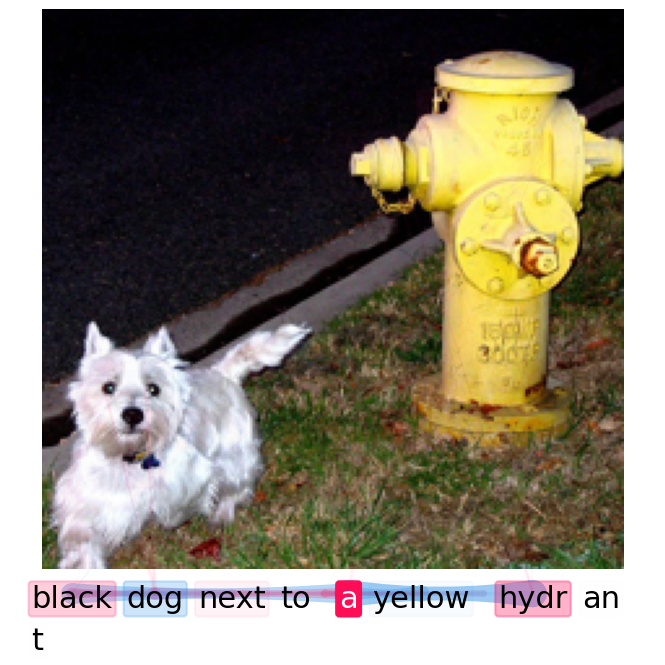

In [11]:
src.plot.plot_image_and_text_together(
    img=input_image_denormalized,
    text=text_tokens,
    image_players=list(range(game.n_players_image)),
    iv=interaction_values,
    plot_interactions=True,
    top_k=30,
    normalize_jointly=True,
    figsize=(6.5, 6.5),
    fontsize=22,
    margin=0.4,
    color_text=True,
    plot_heatmap=True,
    show=False
)
plt.tight_layout(pad=0.15)

### GAME

In [12]:
attribution_values = src.utils.convert_iv_to_first_order(interaction_values)

In [13]:
av_text = src.utils.get_subset(attribution_values, players=players_text)
av_image = src.utils.get_subset(attribution_values, players=list(range(n_players_image)))

In [14]:
def plot_image_token(image, id_token, grid_size=14, patch_size=16):
    id_row = (id_token // grid_size)
    id_col = id_token % grid_size
    print(f'Image token {id_token} from row: {id_row}, column: {id_col}')
    input_token = image[(id_row * patch_size):((id_row + 1) * patch_size), (id_col * patch_size):((id_col + 1) * patch_size), :]
    fig, ax = plt.subplots(figsize=(1, 1))
    ax.imshow(input_token)
    ax.axis("off")
    plt.tight_layout()
    return fig

In [15]:
import numpy as np
k_most_important_tokens_image = 5
id_most_important_tokens_image = np.argpartition(av_image.values[:n_players_image], -k_most_important_tokens_image)[-k_most_important_tokens_image:][::-1]

In [16]:
import matplotlib; print(matplotlib.__version__)


3.10.9


Image token 142 from row: 10, column: 2


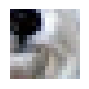

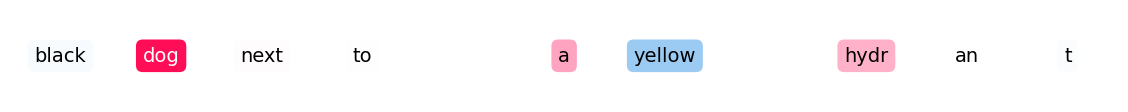

Image token 50 from row: 3, column: 8


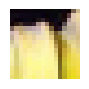

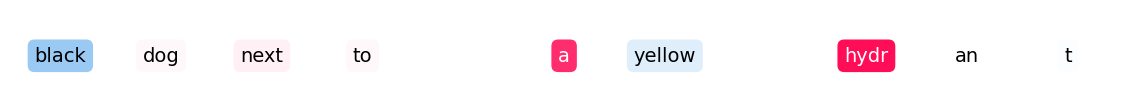

Image token 49 from row: 3, column: 7


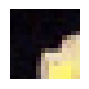

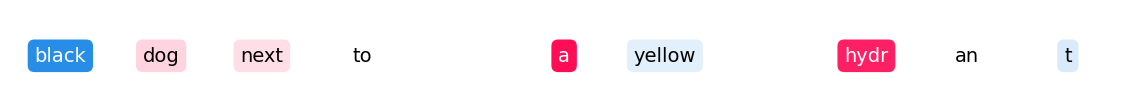

Image token 109 from row: 7, column: 11


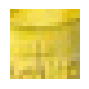

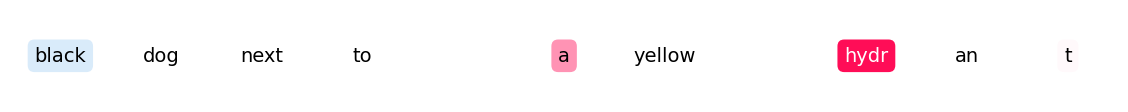

Image token 156 from row: 11, column: 2


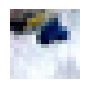

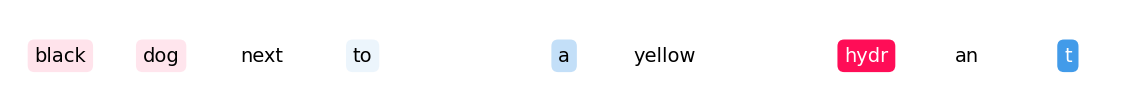

In [17]:
from copy import deepcopy
for id_token_image in id_most_important_tokens_image:
    text_interactions = deepcopy(av_text)
    for i, id_token_text in enumerate(players_text):
        text_interactions[i] = interaction_values.dict_values[(id_token_image, id_token_text)]
    plot_image_token(input_image_denormalized, id_token_image)
    src.plot.plot_sentence(text_interactions, sentence=text_tokens)
    plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


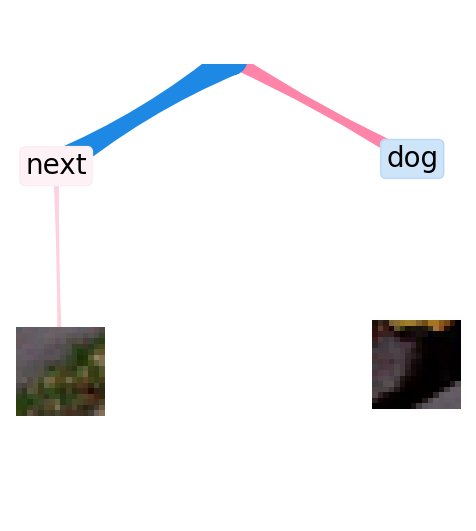

In [18]:
clique = {77, 78, 91, 105, 197, 198}
_ = src.plot.plot_interaction_subset(
    interaction_values,
    clique = clique,
    image_players = list(range(game.n_players_image)),
    img = input_image_denormalized,
    text = text_tokens,
    fontsize = 20,
    image_size = 2,
    edges_size = 3,
    figsize = (5, 5)
)